# Time-Based Analysis

## BUSINESS CASE

1. Jam berapa dalam sehari yang paling banyak terjadi transaksi pembelian?
2. Hari apa dalam seminggu yang memiliki volume order tertinggi?
3. Apakah terdapat peningkatan volume order pada periode akhir tahun dan sekitar Black Friday?

## IMPORT LIBRARY 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order = order = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/orders_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order.head(5)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


### GRAIN

1. tabel order : 1 row merepresntasikan 1 order


### KEY COLUMN 

1. **Tabel `orders`**:
   - `order_id` → identifier untuk setiap order
   - `order_purchase_timestamp` → waktu saat customer melakukan order

### RELATIONSHIP TABLE 

## DATA QUALITY

### ASESSING DATA

In [4]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


1. Untuk kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` masih berbentuk object belum datetime

In [5]:
order.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-04-11 10:48:14,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-08 23:38:46,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [6]:
print('Checking null value')
order.isna().sum()

Checking null value


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

1.  Untuk kolom ```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date``` terdapat missing value

In [7]:
print('Checking duplicated value')
order.duplicated().sum()

Checking duplicated value


0

### CLEANING DATA

## DATA PREPARATION

### MENGUBAH TIPE DATA PADA TABEL ORDER

mengubah kolom ```order_purchase_timestamp```,```order_approved_at```, ```order_delivered_carrier_date```, ```order_delivered_customer_date```,```order_estimated_delivery_date``` menjadi daatetime

In [8]:
order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])

### MENGAMBIL FEATURE UNTUK MENJAWAB BUSINESS CASE

In [9]:
data = order[['order_id','order_purchase_timestamp']]

### MENAMBAH FEATURE JAM, TANGGAL, HARI, BULAN, TAHUN

In [10]:
data['tanggal'] = data['order_purchase_timestamp'].dt.strftime("%d")
data['hari'] = data['order_purchase_timestamp'].dt.strftime("%A")
data['jam'] = data['order_purchase_timestamp'].dt.strftime("%H")
data['bulan'] = data['order_purchase_timestamp'].dt.strftime("%m")
data['tahun'] = data['order_purchase_timestamp'].dt.strftime("%Y")

C:\Users\adien\AppData\Local\Temp\ipykernel_2768\1240924750.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['tanggal'] = data['order_purchase_timestamp'].dt.strftime("%d")
C:\Users\adien\AppData\Local\Temp\ipykernel_2768\1240924750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['hari'] = data['order_purchase_timestamp'].dt.strftime("%A")
C:\Users\adien\AppData\Local\Temp\ipykernel_2768\1240924750.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

## EXPLORATORY DATA ANALYSIS

### 1. Jam berapa dalam sehari yang paling banyak terjadi transaksi pembelian?

In [11]:
data_q1_clean = data[['order_id','jam']]

In [12]:
data_q1 = data_q1_clean.groupby('jam')['order_id'].count().reset_index()
data_q1

,jam,order_id
0,00,2394
1,01,1170
2,02,510
3,03,272
4,04,206
5,05,188
6,06,502
7,07,1231
8,08,2967
9,09,4785


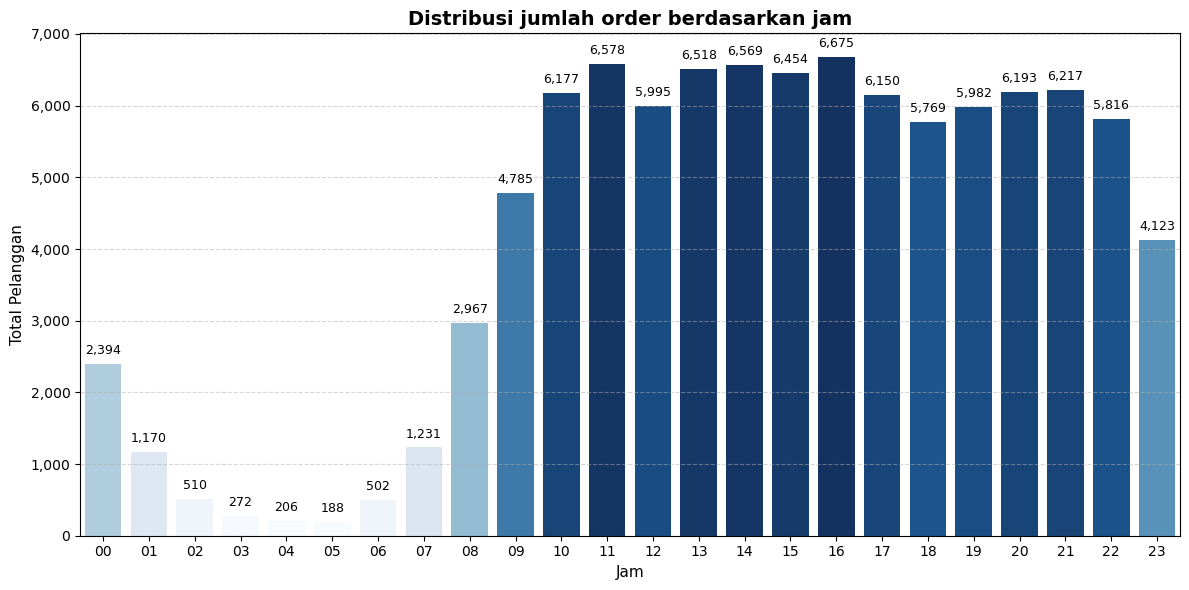

In [13]:
# 1. Mengubah angka menjadi nama hari
# Sesuaikan dictionary ini dengan format data Anda (misal 0-6 atau 1-7)
hour_order =[f"{i:02d}" for i in range(24)]

# Terapkan mapping ke kolom hari (pastikan ini dijalankan sebelum plot)
plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot
ax = sns.barplot(
    data=data_q1,
    x='jam',              
    y='order_id',   
    order=hour_order,
    hue='order_id',       # Menjadikan angka pesanan sebagai dasar perhitungan gradien
    palette='Blues',      # Palet gradien (semakin tinggi angka, semakin gelap warnanya)
    dodge=False,          # Wajib False agar letak batang tidak bergeser ke pinggir
    legend=False          # Mematikan legenda angka hue agar visual tetap bersih
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',     
        padding=5,         
        fontsize=9
    )

# 4. Mengatasi format 1e6 pada sumbu Y (karena sumbu angka sekarang di Y)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Judul dan Label Sumbu
plt.title('Distribusi jumlah order berdasarkan jam', fontsize=14, fontweight='bold')
plt.xlabel('Jam', fontsize=11)
plt.ylabel('Total Pelanggan', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. Aktivitas order tertinggi berdasarkan jam terjadi pada **pukul 16.00**, dengan total **6.675 order**.
2. Aktivitas order tertinggi kedua berdasarkan jam terjadi pada **pukul 11.00**, dengan total **6.578 order**.

### 2. Hari apa dalam seminggu yang memiliki volume order tertinggi?

In [14]:
data_q2_clean = data[['order_id','hari']]

In [15]:
data_q2 = data_q2_clean.groupby('hari')['order_id'].count().reset_index()
data_q2

,hari,order_id
0,Friday,14122
1,Monday,16196
2,Saturday,10887
3,Sunday,11960
4,Thursday,14761
5,Tuesday,15963
6,Wednesday,15552


C:\Users\adien\AppData\Local\Temp\ipykernel_2768\1105869467.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


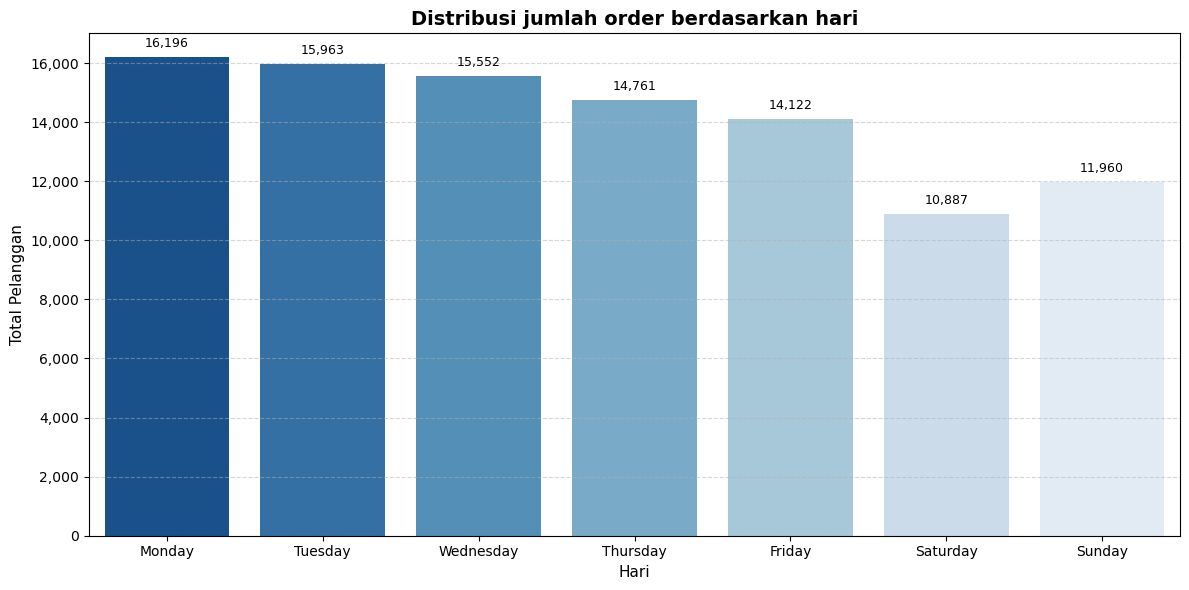

In [16]:
urutan_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
# Jika menggunakan bahasa Indonesia: ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']

# Terapkan mapping ke kolom hari (pastikan ini dijalankan sebelum plot)
plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot
ax = sns.barplot(
    data=data_q2,
    x='hari',              
    y='order_id',   
    order=urutan_hari,
    palette='Blues_r',      # Palet gradien (semakin tinggi angka, semakin gelap warnanya)
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',     
        padding=5,         
        fontsize=9
    )

# 4. Mengatasi format 1e6 pada sumbu Y (karena sumbu angka sekarang di Y)
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Judul dan Label Sumbu
plt.title('Distribusi jumlah order berdasarkan hari', fontsize=14, fontweight='bold')
plt.xlabel('Hari', fontsize=11)
plt.ylabel('Total Pelanggan', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. Aktivitas order tertinggi berdasarkan hari terjadi pada **hari Monday**, dengan total **16.196 order**.
2. Aktivitas order tertinggi kedua berdasarkan hari terjadi pada **hari Tuesday**, dengan total **15.963 order**.

### 3.Apakah terdapat peningkatan volume order pada periode akhir tahun dan sekitar Black Friday?

**CATATAN** : 

Analisis periode akhir tahun dan Black Friday difokuskan pada 2017 karena merupakan satu-satunya tahun dalam dataset yang memiliki data lengkap untuk periode Oktober–Desember serta mencakup tanggal Black Friday 24 November 2017. 

In [17]:
data_q3 = data[['order_id','bulan','tahun','hari','tanggal']]

#### A. Year-End Pattern 2017 

In [18]:
data_q3_a = data_q3[['order_id','bulan','tahun']]

In [19]:
# FILTER DATA HANYA TAHUN 2017 BULAN 0KTOBER - DESEMBER
data_q3_a = data_q3_a[data_q3_a['tahun'] == '2017']
data_q3_a = data_q3_a[data_q3_a['bulan'].isin(['10', '11', '12'])]

In [20]:
data_q3_a

,order_id,bulan,tahun
0,e481f51cbdc54678b7cc49136f2d6af7,10,2017
3,949d5b44dbf5de918fe9c16f97b45f8a,11,2017
17,116f0b09343b49556bbad5f35bee0cdf,12,2017
18,85ce859fd6dc634de8d2f1e290444043,11,2017
19,83018ec114eee8641c97e08f7b4e926f,10,2017
...,...,...,...
99424,6ec4642f9993cc34f826cfb9068e5a2f,11,2017
99429,0e4b26f1fb99fc0f0472dd5f403d36d4,11,2017
99431,b0f4af5c1b06e24fef510703bfe9f0a6,10,2017
99432,cfa78b997e329a5295b4ee6972c02979,12,2017


In [21]:
data_q3_a_clean = data_q3_a.groupby(by=['bulan','tahun'])['order_id'].count().reset_index()
data_q3_a_clean

,bulan,tahun,order_id
0,10,2017,4631
1,11,2017,7544
2,12,2017,5673


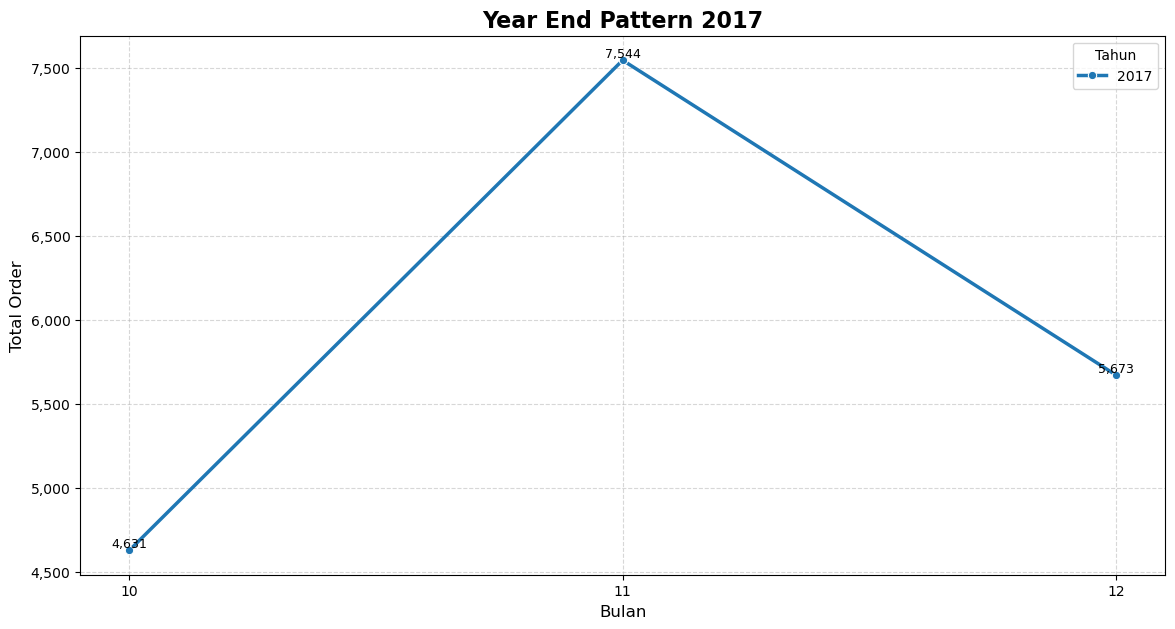

In [22]:
# MENGURUTKAN DATA DARI BULAN 01 - 12
data_q3_a_clean = data_q3_a_clean.sort_values(by='bulan')

plt.figure(figsize=(14, 7)) 

# Membuat Line Chart
sns.lineplot(
    data=data_q3_a_clean, 
    x='bulan', 
    y='order_id', 
    hue='tahun', 
    hue_order=['2017'], 
    marker='o',
    linewidth=2.5
)

# Menambahkan label angka PENUH di setiap titik dengan pemisah ribuan (koma)
for index, row in data_q3_a_clean.iterrows():
    plt.text(
        x=row['bulan'], 
        y=row['order_id'], 
        s=f"{row['order_id']:,.0f}",  
        ha='center',               
        va='bottom',               
        fontsize=9,                
        color='black'              
    )

# Mengatur format sumbu Y agar tidak 1e6 dan menampilkan koma
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.title('Year End Pattern 2017', fontsize=16, fontweight='bold')
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Total Order', fontsize=12)
plt.legend(title='Tahun')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

#### B. Black Friday 2017

In [23]:
data_q3_b = data_q3[['order_id','bulan','tahun','tanggal']]

In [24]:
data_q3_b = data_q3_b[
    (data_q3_b['tahun'] == '2017') &
    (
        ((data_q3_b['bulan'] == '11') & (data_q3_b['tanggal'].between('17', '30'))) |
        ((data_q3_b['bulan'] == '12') & (data_q3_b['tanggal'] == '1'))
    )
]

In [25]:
data_q3_b

,order_id,bulan,tahun,tanggal
3,949d5b44dbf5de918fe9c16f97b45f8a,11,2017,18
18,85ce859fd6dc634de8d2f1e290444043,11,2017,21
41,6ea2f835b4556291ffdc53fa0b3b95e8,11,2017,24
60,68873cf91053cd11e6b49a766db5af1a,11,2017,30
97,6a0a8bfbbe700284feb0845d95e0867f,11,2017,22
...,...,...,...,...
99393,29b199897e15bd5a4b501cf5eee8b948,11,2017,19
99404,a2a701c6f01ddffde8a1bde136ed7d4a,11,2017,26
99412,4146f35ac7a7ef4e39fe344e563c1e3b,11,2017,26
99418,788541a19c0791de0504c5a9cb7e7bd5,11,2017,30


In [26]:
data_q3_b_clean = data_q3_b.groupby(by='tanggal')['order_id'].count().reset_index()
data_q3_b_clean

,tanggal,order_id
0,17,197
1,18,149
2,19,158
3,20,230
4,21,228
5,22,201
6,23,283
7,24,1176
8,25,499
9,26,391


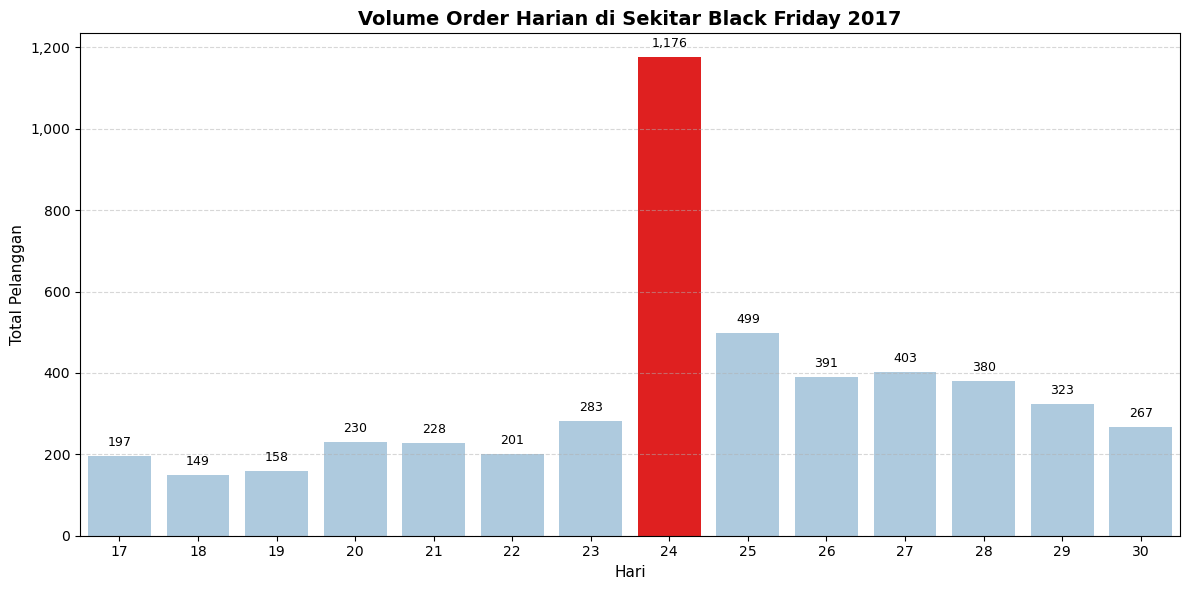

In [27]:
# 1. Membuat Custom Palette untuk Highlight Tanggal 24
# Ganti '24' dengan angka 24 (tanpa kutip) jika tipe datanya integer
# Ganti dengan format lain (misal '2017-11-24') jika tipe datanya tanggal lengkap
custom_colors = ['red' if str(val) == '24' else '#a6cbe6' for val in data_q3_b_clean['tanggal'].unique()]

plt.figure(figsize=(12, 6))

# 2. Membuat Vertical Bar Plot
ax = sns.barplot(
    data=data_q3_b_clean,
    x='tanggal',              
    y='order_id',   
    palette=custom_colors,  # Gunakan custom palette di sini
    hue='tanggal',          # Ditambahkan agar tidak muncul warning di Seaborn versi baru
    legend=False            # Menghilangkan legend karena hue hanya dipakai untuk warna
)

# 3. Menambahkan Label Angka di Atas Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.0f}',      
        padding=5,          
        fontsize=9
    )

# 4. Mengatasi format 1e6 pada sumbu Y
ax.yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 5. Judul dan Label Sumbu
plt.title('Volume Order Harian di Sekitar Black Friday 2017', fontsize=14, fontweight='bold')
plt.xlabel('Hari', fontsize=11)
plt.ylabel('Total Pelanggan', fontsize=11)

# 6. Grid disesuaikan menjadi horizontal (sumbu Y)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout() 
plt.show()

#### KEY INSIGHT

1. **November 2017** memiliki volume order tertinggi pada periode akhir tahun, dengan **7.544** order, dibandingkan **Oktober 2017** dengan **4.631 order** dan **Desember 2017** dengan **5.673 order**.
2. Dalam periode pengamatan **17 November–1 Desember 2017**, volume order menunjukkan peningkatan menjelang Black Friday, terutama dari **228 order** pada **21 November** menjadi **283 order** pada **23 November**, kemudian meningkat tajam menjadi **1.176 order** pada **24 November**.
3. Setelah Black Friday, volume order menurun, dari **499 order** pada **25 November** menjadi **267 order** pada **30 November**. Pola ini menunjukkan bahwa lonjakan order paling tinggi dalam periode pengamatan terjadi pada sekitar tanggal Black Friday.

## KEY FINDINGS 

1. Aktivitas order tertinggi berdasarkan jam terjadi pada **pukul 16.00**, dengan total **6.675 order**.
2. Aktivitas order tertinggi kedua berdasarkan jam terjadi pada **pukul 11.00**, dengan total **6.578 order**.
3. Aktivitas order tertinggi berdasarkan hari terjadi pada **hari Monday**, dengan total **16.196 order**.
4. Aktivitas order tertinggi kedua berdasarkan hari terjadi pada **hari Tuesday**, dengan total **15.963 order**.
5. **November 2017** memiliki volume order tertinggi pada periode akhir tahun, dengan **7.544** order, dibandingkan **Oktober 2017** dengan **4.631 order** dan **Desember 2017** dengan **5.673 order**.
6. Dalam periode pengamatan **17 November–1 Desember 2017**, volume order menunjukkan peningkatan menjelang Black Friday, terutama dari **228 order** pada **21 November** menjadi **283 order** pada **23 November**, kemudian meningkat tajam menjadi **1.176 order** pada **24 November**.
7. Setelah Black Friday, volume order menurun, dari **499 order** pada **25 November** menjadi **267 order** pada **30 November**. Pola ini menunjukkan bahwa lonjakan order paling tinggi dalam periode pengamatan terjadi pada sekitar tanggal Black Friday.

## BUSINESS IMPLICATION

1. Bisnis dapat menyesuaikan kapasitas customer service, order processing, dan fulfillment pada periode dengan aktivitas order yang tinggi, terutama sekitar pukul **16.00** serta hari **Monday dan Tuesday**.
2. Tingginya volume order pada **November 2017** menunjukkan perlunya persiapan kapasitas inventory, seller, fulfillment, dan customer support sebelum memasuki periode dengan aktivitas order yang lebih tinggi.
3. Peningkatan volume order sebelum Black Friday dan lonjakan pada **24 November 2017** menunjukkan pentingnya kesiapan inventory, processing capacity, fulfillment, dan customer service sebelum event berlangsung.
4. Penurunan volume order setelah Black Friday dapat menjadi pertimbangan dalam menyesuaikan kapasitas operasional dan mengevaluasi efektivitas program promosi setelah event berakhir.
